# 02 — Preprocessing
Seattle Airbnb Price Prediction — CSE437

Covers report section **2 (Data Handling and Preprocessing)**: missing values, outliers,
transformation, scaling groundwork. Produces `data/processed/cleaned_listings.csv` for the
next notebook.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append('../src')

import glob
import os
import ast
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import parse_price, parse_list_col

RANDOM_STATE = 42
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

data_journal = {}  # evidence of what changed - printed and saved at the end


In [2]:
csv_candidates = glob.glob('../data/raw/*.csv')
DATA_PATH = max(csv_candidates, key=lambda p: os.path.getsize(p))
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

data_journal['initial_rows'] = df_raw.shape[0]
data_journal['initial_cols'] = df_raw.shape[1]
print("Loaded:", df_raw.shape)


Loaded: (7576, 18)


## 2.4 Transformation — parse price string to float
(Per faculty guidance: parse price first, before anything else.)

In [3]:
df = df_raw.copy()
price_col_candidates = [c for c in df.columns if c.strip().lower() == 'price']
price_col = price_col_candidates[0] if price_col_candidates else 'price'

df['price_clean'] = parse_price(df[price_col])
data_journal['price_nulls_before'] = int(df[price_col].isna().sum())
data_journal['price_nulls_after_parse'] = int(df['price_clean'].isna().sum())
print(df['price_clean'].describe())


count    7576.000000
mean      113.024419
std       122.481780
min        15.000000
25%        65.000000
50%        88.000000
75%       125.000000
max      5900.000000
Name: price_clean, dtype: float64


In [4]:
before = len(df)
df = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()
data_journal['rows_dropped_invalid_price'] = before - len(df)
print(f"Dropped {before - len(df)} rows with missing/zero/invalid price")


Dropped 0 rows with missing/zero/invalid price


## 2.2 Missing values
Strategy per column, with justification for anything dropped.

In [5]:
df = df_raw.copy()

# The uploaded legacy export has an unnamed CSV index and uses room_id as its listing key.
index_cols = [c for c in df.columns if c.lower().startswith('unnamed:')]
if index_cols:
    df = df.drop(columns=index_cols)
    data_journal['dropped_csv_index_cols'] = index_cols

n_duplicate_rows = int(df.duplicated().sum())
n_duplicate_room_ids = int(df['room_id'].duplicated().sum()) if 'room_id' in df.columns else 0
data_journal['duplicate_rows_before'] = n_duplicate_rows
data_journal['duplicate_room_ids_before'] = n_duplicate_room_ids
if n_duplicate_rows:
    df = df.drop_duplicates().copy()
if 'room_id' in df.columns:
    df = df.drop_duplicates(subset='room_id', keep='first').copy()
data_journal['rows_removed_as_duplicates'] = data_journal['initial_rows'] - len(df)

price_col_candidates = [c for c in df.columns if c.strip().lower() == 'price']
price_col = price_col_candidates[0] if price_col_candidates else 'price'
df['price_clean'] = parse_price(df[price_col])
data_journal['price_nulls_before'] = int(df[price_col].isna().sum())
data_journal['price_nulls_after_parse'] = int(df['price_clean'].isna().sum())
print(df['price_clean'].describe())

# Normalize numeric fields because the legacy export may mix empty strings and numbers.
legacy_numeric_cols = [
    'reviews', 'overall_satisfaction', 'accommodates', 'bedrooms', 'bathrooms',
    'latitude', 'longitude'
]
for col in legacy_numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

before = len(df)
df = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()
data_journal['rows_dropped_invalid_price'] = before - len(df)
print(f"Dropped {before - len(df)} rows with missing/zero/invalid price")

# Features available in this export and useful for the research questions.
if 'reviews' in df.columns:
    df['reviews'] = df['reviews'].fillna(0)
    df['has_reviews'] = (df['reviews'] > 0).astype(int)
if 'overall_satisfaction' in df.columns:
    df['has_satisfaction'] = df['overall_satisfaction'].notna().astype(int)
    satisfaction_median = df['overall_satisfaction'].median()
    df['overall_satisfaction'] = df['overall_satisfaction'].fillna(satisfaction_median)
    data_journal['overall_satisfaction_median'] = float(satisfaction_median)
    data_journal['overall_satisfaction_imputed'] = int(df['has_satisfaction'].eq(0).sum())

# Text length captures listing and address detail without one-hot encoding high-cardinality text.
for col, feature in [('name', 'name_length'), ('address', 'address_length')]:
    if col in df.columns:
        df[feature] = df[col].fillna('').astype(str).str.len()

missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

# Drop columns >70% missing - too sparse to impute meaningfully.
high_missing_cols = missing_pct[missing_pct > 70].index.tolist()
data_journal['dropped_high_missing_cols'] = high_missing_cols
df = df.drop(columns=[c for c in high_missing_cols if c in df.columns])
print("Dropped columns (>70% missing):", high_missing_cols)

# Property-size and coordinate fields use medians; room type provides a useful local grouping when available.
numeric_fill_cols = [c for c in [
    'bathrooms', 'bedrooms', 'accommodates', 'latitude', 'longitude'
] if c in df.columns]
for c in numeric_fill_cols:
    if 'room_type' in df.columns:
        df[c] = df.groupby('room_type')[c].transform(lambda s: s.fillna(s.median()))
    df[c] = df[c].fillna(df[c].median())
data_journal['numeric_fill_cols_grouped_median'] = numeric_fill_cols

# Retain a final check so no predictor silently reaches modeling with missing values.
data_journal['missing_cells_after_cleaning'] = int(df.isna().sum().sum())
print("Remaining total missing cells:", data_journal['missing_cells_after_cleaning'])
print("Cleaned shape:", df.shape)

count    7576.000000
mean      113.024419
std       122.481780
min        15.000000
25%        65.000000
50%        88.000000
75%       125.000000
max      5900.000000
Name: price_clean, dtype: float64
Dropped 0 rows with missing/zero/invalid price
Dropped columns (>70% missing): []
Remaining total missing cells: 0
Cleaned shape: (7576, 22)


## 2.3 Outliers
Detection method: 1st/99th percentile capping on price. Report how many points were flagged.

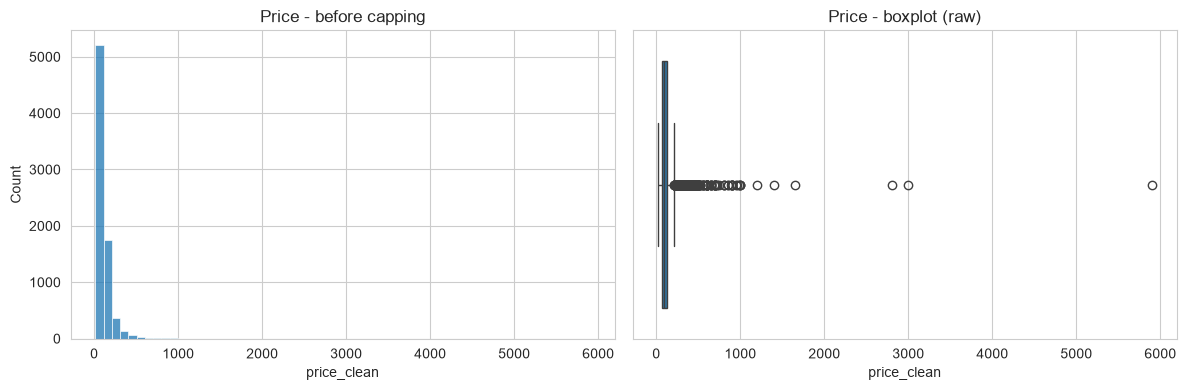

Capped 112 rows (1.48%) into [25.00, 500.00]


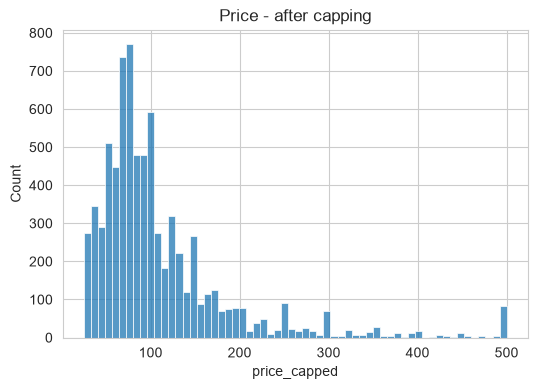

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['price_clean'], bins=60, ax=axes[0])
axes[0].set_title('Price - before capping')
sns.boxplot(x=df['price_clean'], ax=axes[1])
axes[1].set_title('Price - boxplot (raw)')
plt.tight_layout()
plt.savefig('../figures/02_price_before_capping.png', dpi=120)
plt.show()

q_low, q_high = df['price_clean'].quantile([0.01, 0.99])
df['price_capped'] = df['price_clean'].clip(q_low, q_high)
n_capped = int(((df['price_clean'] < q_low) | (df['price_clean'] > q_high)).sum())
data_journal['price_cap_bounds'] = (float(q_low), float(q_high))
data_journal['n_rows_capped'] = n_capped
print(f"Capped {n_capped} rows ({n_capped/len(df):.2%}) into [{q_low:.2f}, {q_high:.2f}]")

plt.figure(figsize=(6, 4))
sns.histplot(df['price_capped'], bins=60)
plt.title('Price - after capping')
plt.savefig('../figures/02_price_after_capping.png', dpi=120)
plt.show()


## 2.4 Transformation — log target

Skew before log: 2.4849179164190236
Skew after log: 0.40877847223776226


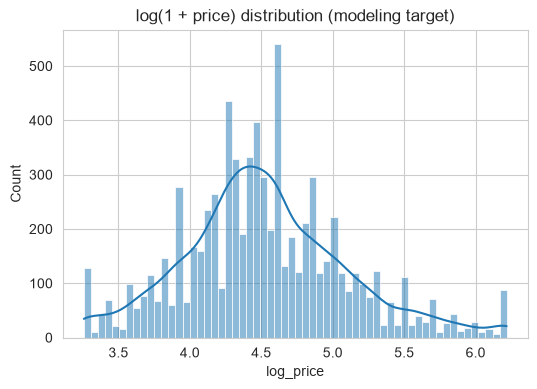

In [7]:
df['log_price'] = np.log1p(df['price_capped'])
data_journal['skew_before_log'] = float(df['price_capped'].skew())
data_journal['skew_after_log'] = float(df['log_price'].skew())
print("Skew before log:", data_journal['skew_before_log'])
print("Skew after log:", data_journal['skew_after_log'])

plt.figure(figsize=(6, 4))
sns.histplot(df['log_price'], bins=60, kde=True)
plt.title('log(1 + price) distribution (modeling target)')
plt.savefig('../figures/02_log_price_distribution.png', dpi=120)
plt.show()


## Amenities & host_verifications -> flags
(Not full one-hot encoding, per faculty guidance.)

In [8]:
if 'amenities' in df.columns:
    df['amenities_list'] = df['amenities'].apply(parse_list_col)
    df['n_amenities'] = df['amenities_list'].apply(len)
    common_amenities = ['Wifi', 'Kitchen', 'Free parking', 'Air conditioning',
                         'Washer', 'Dryer', 'Pool', 'Hot tub', 'Elevator',
                         'Pets allowed', 'Self check-in', 'TV', 'Heating']
    for amenity in common_amenities:
        flag_name = 'has_' + amenity.lower().replace(' ', '_').replace('-', '_')
        df[flag_name] = df['amenities_list'].apply(
            lambda lst: any(amenity.lower() in str(a).lower() for a in lst)
        ).astype(int)
    data_journal['amenity_flags_created'] = [
        'has_' + a.lower().replace(' ', '_').replace('-', '_') for a in common_amenities
    ] + ['n_amenities']

if 'host_verifications' in df.columns:
    df['host_verifications_list'] = df['host_verifications'].apply(parse_list_col)
    common_verifications = ['email', 'phone', 'work_email', 'identity_manual']
    for v in common_verifications:
        df[f'verified_{v}'] = df['host_verifications_list'].apply(lambda lst: v in lst).astype(int)
    df['n_verifications'] = df['host_verifications_list'].apply(len)
    data_journal['verification_flags_created'] = [f'verified_{v}' for v in common_verifications] + ['n_verifications']

print("Amenity/verification flags created.")


Amenity/verification flags created.


In [9]:
if 'neighbourhood_cleansed' in df.columns:
    top_neighbourhoods = df['neighbourhood_cleansed'].value_counts().nlargest(15).index
    df['neighbourhood_grouped'] = df['neighbourhood_cleansed'].where(
        df['neighbourhood_cleansed'].isin(top_neighbourhoods), 'Other'
    )
    data_journal['n_neighbourhoods_raw'] = int(df['neighbourhood_cleansed'].nunique())
    data_journal['n_neighbourhoods_grouped'] = int(df['neighbourhood_grouped'].nunique())

if 'property_type' in df.columns:
    top_property = df['property_type'].value_counts().nlargest(10).index
    df['property_type_grouped'] = df['property_type'].where(
        df['property_type'].isin(top_property), 'Other'
    )

print("Categorical grouping done. Shape:", df.shape)


Categorical grouping done. Shape: (7576, 24)


## 2.5 Before and after summary

In [10]:
summary_table = pd.DataFrame([
    {'stage': 'raw', 'rows': data_journal['initial_rows'], 'cols': data_journal['initial_cols']},
    {'stage': 'after price validity filter', 'rows': data_journal['initial_rows'] - data_journal['rows_dropped_invalid_price'], 'cols': data_journal['initial_cols'] + 1},
    {'stage': 'after cleaning (final)', 'rows': df.shape[0], 'cols': df.shape[1]},
])
print(summary_table)

print("\n" + "=" * 60)
print("DATA CLEANING JOURNAL (evidence of what changed)")
print("=" * 60)
for k, v in data_journal.items():
    print(f"{k}: {v}")


                         stage  rows  cols
0                          raw  7576    18
1  after price validity filter  7576    19
2       after cleaning (final)  7576    24

DATA CLEANING JOURNAL (evidence of what changed)
initial_rows: 7576
initial_cols: 18
price_nulls_before: 0
price_nulls_after_parse: 0
rows_dropped_invalid_price: 0
dropped_csv_index_cols: ['Unnamed: 0']
duplicate_rows_before: 0
duplicate_room_ids_before: 0
rows_removed_as_duplicates: 0
overall_satisfaction_median: 5.0
overall_satisfaction_imputed: 1473
dropped_high_missing_cols: []
numeric_fill_cols_grouped_median: ['bathrooms', 'bedrooms', 'accommodates', 'latitude', 'longitude']
missing_cells_after_cleaning: 0
price_cap_bounds: (25.0, 500.0)
n_rows_capped: 112
skew_before_log: 2.4849179164190236
skew_after_log: 0.40877847223776226


## Save cleaned output for the next notebook

In [11]:
os.makedirs('../data/processed', exist_ok=True)
df.to_csv('../data/processed/cleaned_listings.csv', index=False)
print("Saved: ../data/processed/cleaned_listings.csv", df.shape)


Saved: ../data/processed/cleaned_listings.csv (7576, 24)
